# CSIA6853 - Natural Language Processing - 2026
**Name:** LF Kalashe  
**Student Number:** 2023575000  
**Project:** A Retrieval-Augmented Question Answering System for Software Engineering Course Documents

---
## Project Reminder
* **Project Title:** A Retrieval-Augmented Question Answering System for Software Engineering Course Documents.
* **Chosen Track:** Track B (RAG-QA).
* **Goal:** To develop a system that enables users to ask natural-language questions about a curated collection of Software Engineering lecture slides. The system retrieves relevant document sections based on semantic similarity and generates an answer grounded in those sections.
* **Dataset:** Approximately 11 lecture materials (PDF format) from the 3rd-year Software Engineering module.

---
## Install Dependencies

In [ ]:
!pip install langchain langchain-community pymupdf sentence-transformers faiss-cpu scikit-learn pandas matplotlib seaborn openai --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


---
## 1. Data Loading

We load the PDFs using LangChain's `PyMuPDFLoader`. Unlike PyPDF2, this loader:
- Preserves table structure and column relationships.
- Loads the document **one page at a time**, giving us a natural chunk boundary.
- Automatically attaches metadata to every page: source filename, page number, and total pages.

Metadata is critical for RAG — it lets the system tell users exactly which document and page an answer came from.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import drive

# Define a central folder path for your project
project_path = '/content/drive/MyDrive/CSIA6853_Assignment4/'

import os
# This automatically creates the folder in your Drive if it doesn't exist yet
os.makedirs(project_path, exist_ok=True)

print(f"Drive mounted! Project folder ready at: {project_path}")

✅ Drive mounted! Project folder ready at: /content/drive/MyDrive/CSIA6853_Assignment4/


In [ ]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_community.document_loaders import PyMuPDFLoader

# We use the project_path defined earlier during the Drive mount
project_path = '/content/drive/MyDrive/CSIA6853_Assignment4/'

print(f"Scanning for PDFs in: {project_path}")

data = []

# Iterate through all files in your Google Drive folder
for filename in os.listdir(project_path):
    if filename.lower().endswith('.pdf'):
        file_path = os.path.join(project_path, filename)
        try:
            # Load the PDF directly from the Drive path
            loader = PyMuPDFLoader(file_path)
            pages  = loader.load()
            for page in pages:
                data.append({
                    'document_name': filename,
                    'page_number':   page.metadata.get('page', 0) + 1,
                    'total_pages':   page.metadata.get('total_pages', len(pages)),
                    'raw_text':      page.page_content
                })
            print(f"Loaded: {filename} ({len(pages)} pages)")
        except Exception as e:
            print(f"Error loading {filename}: {e}")

df = pd.DataFrame(data)

print(f'\n--- Summary ---')
print(f'Total pages loaded : {len(df)}')
print(f'Unique documents   : {df["document_name"].nunique()}')
print('Columns            :', list(df.columns))
print('-------------------\n')

df.info()
print()
display(df[['document_name', 'page_number', 'total_pages', 'raw_text']].head(5))

Scanning for PDFs in: /content/drive/MyDrive/CSIA6853_Assignment4/
Loaded: Chapter 1.pdf (50 pages)
Loaded: Chapter 4.pdf (38 pages)
Loaded: Chapter 2.pdf (45 pages)
Loaded: Chapter 6.pdf (18 pages)
Loaded: Chapter 9.pdf (19 pages)
Loaded: Chapter 3.pdf (45 pages)
Loaded: Chapter 13.pdf (101 pages)
Loaded: Chapter 14.pdf (29 pages)
Loaded: Chapter 16.pdf (34 pages)
Loaded: Chapter 15.pdf (19 pages)

--- Summary ---
Total pages loaded : 398
Unique documents   : 10
Columns            : ['document_name', 'page_number', 'total_pages', 'raw_text']
-------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   document_name  398 non-null    object
 1   page_number    398 non-null    int64 
 2   total_pages    398 non-null    int64 
 3   raw_text       398 non-null    object
dtypes: int64(2), object(2)
memory usage: 12.6+ KB



,document_name,page_number,total_pages,raw_text
0,Chapter 1.pdf,1,50,Object-Oriented and \nClassical Software \nEng...
1,Chapter 1.pdf,2,50,CHAPTER 1\nTHE SCOPE OF\n SOFTWARE \nENGINEERING
2,Chapter 1.pdf,3,50,Introduction\n• What is software engineering?\...
3,Chapter 1.pdf,4,50,1.1 Historical Aspects\n• Term software engine...
4,Chapter 1.pdf,5,50,1.1 Historical Aspects (continue)\n\nData on ...


---
## 1.2. Data Quality Checks

Before preprocessing we check for:
1. Missing or null text values (image-only pages that extracted no text).
2. Duplicate pages.
3. Word count distribution — to understand the size of our corpus and inform chunking decisions.

--- Data Quality Check ---

Missing values per column:
document_name    0
page_number      0
total_pages      0
raw_text         0
dtype: int64

Rows after removing empty pages: 398
Duplicate pages found: 0

Page word count statistics:
count    398.000000
mean      49.304020
std       24.339135
min        3.000000
25%       32.000000
50%       48.000000
75%       63.000000
max      176.000000
Name: word_count, dtype: float64


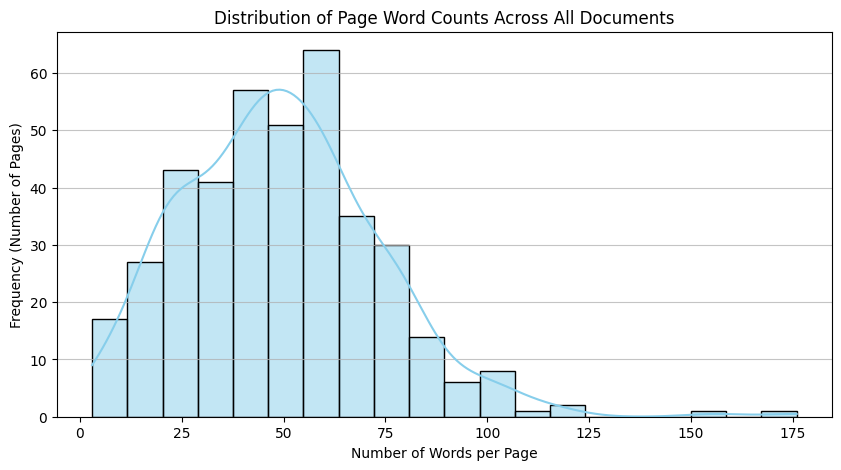


--- Pages per Document ---
document_name
Chapter 1.pdf      50
Chapter 13.pdf    101
Chapter 14.pdf     29
Chapter 15.pdf     19
Chapter 16.pdf     34
Chapter 2.pdf      45
Chapter 3.pdf      45
Chapter 4.pdf      38
Chapter 6.pdf      18
Chapter 9.pdf      19
Name: page_number, dtype: int64


In [ ]:
print('--- Data Quality Check ---')

# 1. Missing values
print('\nMissing values per column:')
print(df.isnull().sum())

df = df.dropna(subset=['raw_text'])
df = df[df['raw_text'].str.strip() != '']
print(f'\nRows after removing empty pages: {len(df)}')

# 2. Duplicates
dups = df.duplicated(subset=['document_name', 'page_number']).sum()
print(f'Duplicate pages found: {dups}')
if dups > 0:
    df = df.drop_duplicates(subset=['document_name', 'page_number'])

# 3. Word count per page
df['word_count'] = df['raw_text'].apply(lambda x: len(str(x).split()))
print('\nPage word count statistics:')
print(df['word_count'].describe())

# 4. Visualise distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Page Word Counts Across All Documents')
plt.xlabel('Number of Words per Page')
plt.ylabel('Frequency (Number of Pages)')
plt.grid(axis='y', alpha=0.75)
plt.show()

print('\n--- Pages per Document ---')
print(df.groupby('document_name')['page_number'].max())

### Observations

* **Zero missing values and zero duplicates** — the extraction was clean.
* **Mean page length is approximately 49 words.** This is an important finding: the corpus consists of lecture slides, not prose documents. Each page is already a self-contained semantic unit.
* **Chunking implication:** The originally planned 300-token and 500-token chunk sizes would be larger than most individual pages, causing unrelated slides to be merged. The retrieval strategy is therefore adjusted — see Section 6.

---
## 2. Text Preprocessing Pipeline

**Key decisions for RAG:**

* **No lowercasing.** Sentence-Transformer embeddings are case-insensitive internally. Lowercasing destroys domain acronyms such as `OOP`, `SDLC`, `APS`, and `UFS`.
* **No punctuation removal.** Punctuation encodes sentence boundaries, list structure (e.g. `(a), (b), (c)`), and meaning. Removing it damages the context the LLM needs to generate coherent answers.
* **Domain-specific noise removal only.** Repetitive university header lines and UFS URLs appear on every slide and add no semantic value. These are removed with targeted regular expressions.
* **Whitespace normalisation.** Newlines and tabs are collapsed into single spaces.

In [ ]:
def clean_text_for_rag(text):
    """
    Cleans raw PDF text for a RAG pipeline.
    - No lowercasing (preserves acronyms).
    - No punctuation removal (preserves structure and meaning).
    - Removes repetitive UFS headers and URLs only.
    """
    if not isinstance(text, str):
        return ''

    # Remove university header block
    text = re.sub(
        r'UNIVERSITY OF THE FREE STATE.*?YUNIVESITHI YA FREISTATA',
        ' ', text, flags=re.IGNORECASE | re.DOTALL
    )

    # Remove UFS URLs — handles PyMuPDF markdown format [text](url) and plain URLs
    text = re.sub(r'\[www\.ufs\.ac\.za[^\]]*\]\([^)]*\)', ' ', text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'www\.ufs\.ac\.za\S*', ' ', text)

    # Normalise whitespace
    text = re.sub(r'[\n\t\r]+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text).strip()

    return text


df['cleaned_text']       = df['raw_text'].apply(clean_text_for_rag)
df['cleaned_word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))

# Drop pages that are empty after cleaning (pure header slides with no content)
df = df[df['cleaned_word_count'] > 3].reset_index(drop=True)

# Verify case and punctuation are preserved
sample = df['cleaned_text'].iloc[0]
print('Case preserved      :', any(c.isupper() for c in sample))
print('Punctuation present :', any(c in '.,:;()[]?!' for c in sample))

print('\n--- BEFORE ---')
print(df['raw_text'].iloc[1][:400])
print('\n--- AFTER ---')
print(df['cleaned_text'].iloc[1][:400])

Case preserved      : True
Punctuation present : True

--- BEFORE ---
CHAPTER 1
THE SCOPE OF
 SOFTWARE 
ENGINEERING

--- AFTER ---
CHAPTER 1 THE SCOPE OF SOFTWARE ENGINEERING


---
## 2.1 Chunking Strategy

Because the corpus averages 49 words per page, we use two conditions:

* **Condition A — Page-level:** Each page is one retrieval unit. No further splitting needed since slides are already self-contained.
* **Condition B — 75-word sub-chunks with 15-word overlap:** For the longer pages (top 25% that exceed 75 words), this provides finer-grained retrieval. Short pages remain a single chunk.

All metadata (`document_name`, `page_number`, `total_pages`, `chunk_id`) is preserved on every chunk row.

In [ ]:
def make_sub_chunks(text, chunk_size=75, overlap=15):
    words = text.split()
    if len(words) <= chunk_size:
        return [text]
    step   = chunk_size - overlap
    chunks = []
    for i in range(0, len(words), step):
        chunk = ' '.join(words[i : i + chunk_size])
        if chunk:
            chunks.append(chunk)
        if i + chunk_size >= len(words):
            break
    return chunks




## 2.2 Chunk Size Comparison

In [ ]:
# --- Condition A: one row per page ---
corpus_A = []
for _, row in df.iterrows():
    corpus_A.append({
        'chunk_id':      f"{row['document_name']}_p{row['page_number']}",
        'text':          row['cleaned_text'],
        'document_name': row['document_name'],
        'page_number':   row['page_number'],
        'total_pages':   row['total_pages'],
    })
df_A = pd.DataFrame(corpus_A)

# --- Condition B: overlapping 75-word sub-chunks ---
corpus_B = []
for _, row in df.iterrows():
    for ci, chunk_text in enumerate(make_sub_chunks(row['cleaned_text'], 75, 15)):
        corpus_B.append({
            'chunk_id':      f"{row['document_name']}_p{row['page_number']}_c{ci}",
            'text':          chunk_text,
            'document_name': row['document_name'],
            'page_number':   row['page_number'],
            'total_pages':   row['total_pages'],
        })
df_B = pd.DataFrame(corpus_B)

print(f'Condition A — page-level chunks  : {len(df_A)}')
print(f'Condition B — 75-word sub-chunks : {len(df_B)}')
print('\nCondition A preview:')
display(df_A[['chunk_id', 'document_name', 'page_number', 'text']].head(5))
print("")
print("")
print("")
display(df_B[['chunk_id', 'document_name', 'page_number', 'text']].head(5))



Condition A — page-level chunks  : 393
Condition B — 75-word sub-chunks : 428

Condition A preview:


,chunk_id,document_name,page_number,text
0,Chapter 1.pdf_p1,Chapter 1.pdf,1,Object-Oriented and Classical Software Enginee...
1,Chapter 1.pdf_p2,Chapter 1.pdf,2,CHAPTER 1 THE SCOPE OF SOFTWARE ENGINEERING
2,Chapter 1.pdf_p3,Chapter 1.pdf,3,Introduction • What is software engineering? –...
3,Chapter 1.pdf_p4,Chapter 1.pdf,4,1.1 Historical Aspects • Term software enginee...
4,Chapter 1.pdf_p5,Chapter 1.pdf,5,1.1 Historical Aspects (continue)  Data on pr...


,chunk_id,document_name,page_number,text
0,Chapter 1.pdf_p1_c0,Chapter 1.pdf,1,Object-Oriented and Classical Software Enginee...
1,Chapter 1.pdf_p2_c0,Chapter 1.pdf,2,CHAPTER 1 THE SCOPE OF SOFTWARE ENGINEERING
2,Chapter 1.pdf_p3_c0,Chapter 1.pdf,3,Introduction • What is software engineering? –...
3,Chapter 1.pdf_p4_c0,Chapter 1.pdf,4,1.1 Historical Aspects • Term software enginee...
4,Chapter 1.pdf_p5_c0,Chapter 1.pdf,5,1.1 Historical Aspects (continue)  Data on pr...


In [ ]:
import pandas as pd
import os

project_path = '/content/drive/MyDrive/CSIA6853_Assignment4/'
os.makedirs(project_path, exist_ok=True)

# Save both dataframes
df_A.to_csv(project_path + 'df_A_page_level.csv', index=False)
df_B.to_csv(project_path + 'df_B_sub_chunks.csv', index=False)

print(f"Data successfully saved to {project_path}")

✅ Data successfully saved to /content/drive/MyDrive/CSIA6853_Assignment4/
